In [360]:
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [361]:
sns.set_theme(style="ticks", context="paper")

In [362]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.family': 'serif',        # Standard for research papers
    'font.serif': ['Calibri', 'DejaVu Serif'],
    'font.size': 24,               # Larger base size
    'axes.labelsize': 24,          # X and Y axis labels
    'axes.titlesize': 36,          # Subplot titles
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 36,        # Main figure title
    'axes.grid': True,             # Keep grid but make it subtle
    'grid.alpha': 0.3,
    'savefig.dpi': 300,            # High resolution for publication
    'savefig.bbox': 'tight'        # Prevent clipping labels
})

In [363]:
sns.set_palette("colorblind")

In [364]:
MESH_RESOLUTIONS = {
    'Suzanne': [('4K', 3936), ('16K', 15744), ('63K', 62976), ('252K', 251904)],
    'Dragon':  [('3K', 3402), ('14K', 13614), ('54K', 54456), ('218K', 217826)],
    'Plane':   [('4K', 4352), ('17K', 16896), ('67K', 66560), ('264K', 264192)],
}

In [365]:
def load_data():
    files = glob.glob("benchall-*.csv")
    summary_list = []
    frames_list = []
    
    for f in files:
        with open(f, 'r') as file:
            header = file.readline().strip('# \n')
            meta = dict(item.split('=') for item in header.split(','))
        
        df = pd.read_csv(f, comment='#')
        method = meta['method']
        deformation = meta['deformation']
        triangles = int(meta['triangles'])
        
        # Determine mesh from filename
        mesh_name = "Unknown"
        for m in MESH_RESOLUTIONS.keys():
            if m.lower() in f.lower():
                mesh_name = m
                break
        
        # Calculate stats for summary plots
        stats = df.mean(numeric_only=True).to_dict()
        stats.update(meta)
        stats['mesh'] = mesh_name
        stats['triangles'] = triangles
        summary_list.append(stats)
        
        # Prepare frame-by-frame data for timeline
        df_f = df.copy()
        df_f['method'] = method
        df_f['deformation'] = deformation
        df_f['mesh'] = mesh_name
        df_f['triangles'] = triangles
        frames_list.append(df_f)
            
    df_stats = pd.DataFrame(summary_list)
    df_frames = pd.concat(frames_list) if frames_list else pd.DataFrame()
    
    # Force categorical order for methods
    m_order = ['RefitRotate', 'KineticBVH', 'DynamicBVH', 'AwareBVH']
    if not df_stats.empty:
        df_stats['method'] = pd.Categorical(df_stats['method'], categories=m_order, ordered=True)
    if not df_frames.empty:
        df_frames['method'] = pd.Categorical(df_frames['method'], categories=m_order, ordered=True)
        
    return df_stats, df_frames

df_stats, df_frames = load_data()

# Styling for overlapping lines in Fig 4
method_styles = {
    'RefitRotate': {'ls': '-',  'lw': 4,   'alpha': 0.6, 'marker': 'o', 'color': 'gray'},
    'DynamicBVH':  {'ls': '--', 'lw': 2,   'alpha': 1.0, 'marker': 's', 'color': 'orange'},
    'KineticBVH':  {'ls': ':',  'lw': 2,   'alpha': 1.0, 'marker': '^', 'color': 'green'},
    'AwareBVH':    {'ls': '-',  'lw': 2.5, 'alpha': 1.0, 'marker': 'D', 'color': 'blue'}
}


[FIG 1: Scaling Curves (Localized Deformation)]
  - Suzanne: 4 methods tested. Triangles: 967 to 251,904. Update Time: 0.13ms to 218.02ms.
  - Dragon : 4 methods tested. Triangles: 3,402 to 217,816. Update Time: 0.17ms to 106.61ms.
  - Plane  : 4 methods tested. Triangles: 4,352 to 264,192. Update Time: 0.42ms to 210.19ms.


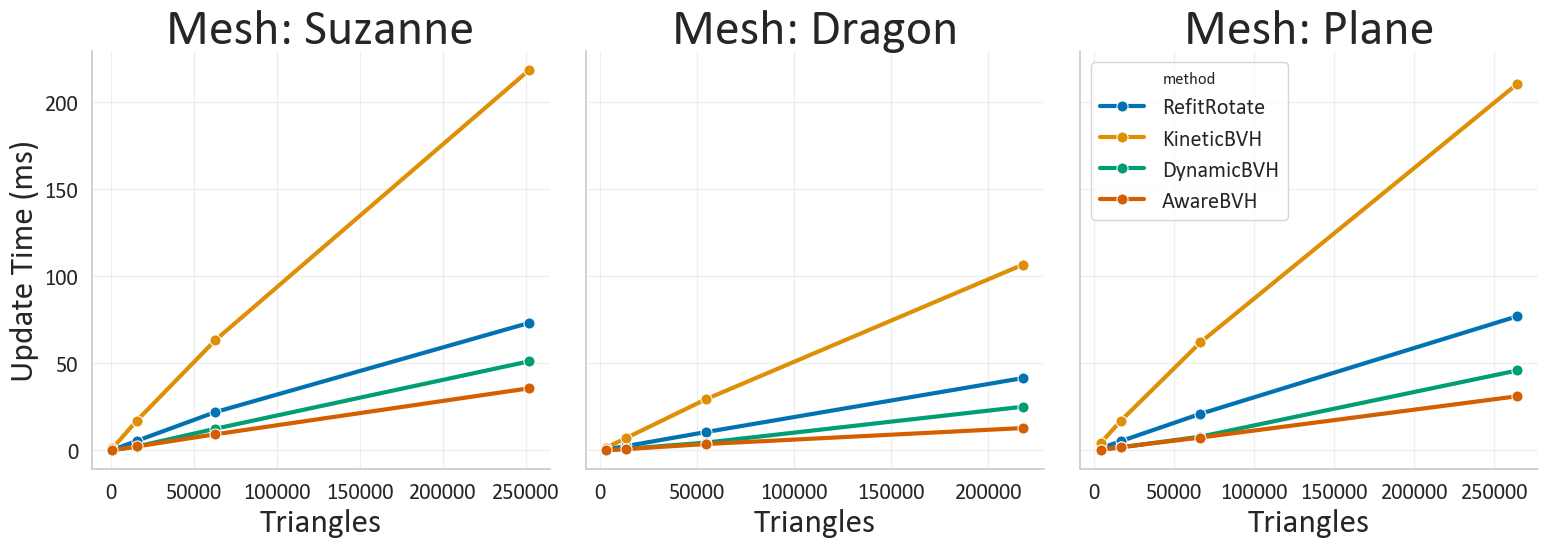

In [366]:
# --- FIG 1: Scaling Curves (Localized Deformation) ---
print("\n[FIG 1: Scaling Curves (Localized Deformation)]")
# sharey=True natively hides interior y-labels
fig1, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
for i, mesh in enumerate(['Suzanne', 'Dragon', 'Plane']):
    data = df_stats[(df_stats['mesh'] == mesh) & (df_stats['deformation'] == 'Localized')].sort_values('triangles')
    if not data.empty:
        sns.lineplot(data=data, x='triangles', y='updateMs', hue='method', marker='o', ax=axes[i], linewidth=3, markersize=8)
        axes[i].set_title(f"Mesh: {mesh}")
        axes[i].set_xlabel("Triangles")
        
        # Keep y-label only on the far left
        if i == 0:
            axes[i].set_ylabel("Update Time (ms)")
        else:
            axes[i].set_ylabel("")

        # Ensure legend is only on the rightmost plot
        leg = axes[i].get_legend()
        if leg and i < 2: 
            leg.remove()
        
        sns.despine(ax=axes[i]) # Removes top & right axis lines
        
        # Print summary statistics including Update Time (ms) range
        min_tris, max_tris = data['triangles'].min(), data['triangles'].max()
        min_time, max_time = data['updateMs'].min(), data['updateMs'].max()
        print(f"  - {mesh:7}: {data['method'].nunique()} methods tested. "
              f"Triangles: {min_tris:,} to {max_tris:,}. "
              f"Update Time: {min_time:.2f}ms to {max_time:.2f}ms.")

plt.tight_layout()
plt.savefig("fig1_scaling.pdf")


[FIG 2: Overhead at Maximum Resolution (Localized)]


C:\Users\o1a2h\AppData\Local\Temp\ipykernel_31468\2014720014.py:4: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  max_tris_mask = data_loc.groupby('mesh')['triangles'].transform(max)


  - Dragon : Best method is AwareBVH (12.87ms).
  - Dragon : Second is DynamicBVH (25.10ms).
  - Dragon : Third is RefitRotate (41.53ms).
  - Dragon : Worst is KineticBVH (106.61ms).
  - Plane  : Best method is AwareBVH (31.09ms).
  - Plane  : Second is DynamicBVH (45.87ms).
  - Plane  : Third is RefitRotate (76.94ms).
  - Plane  : Worst is KineticBVH (210.19ms).
  - Suzanne: Best method is AwareBVH (35.64ms).
  - Suzanne: Second is DynamicBVH (51.08ms).
  - Suzanne: Third is RefitRotate (73.12ms).
  - Suzanne: Worst is KineticBVH (218.02ms).


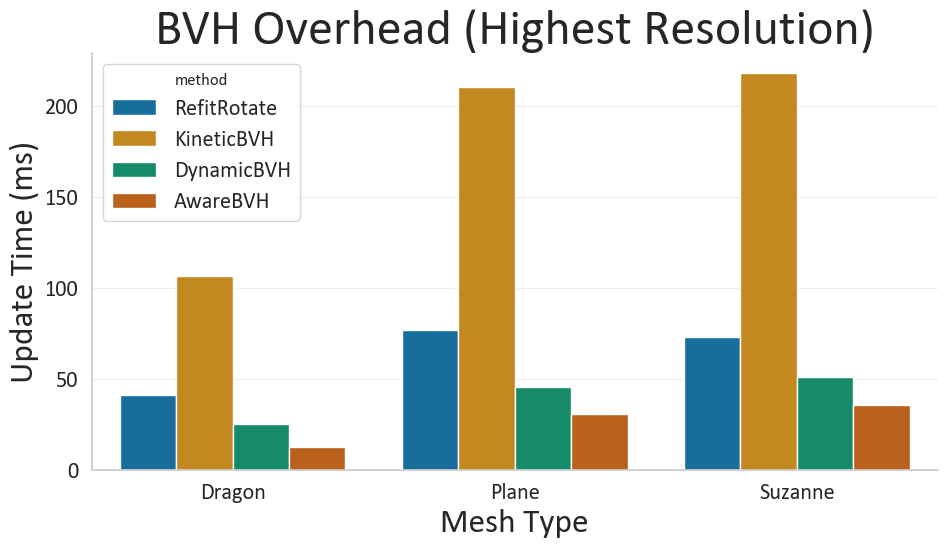

In [367]:
print("\n[FIG 2: Overhead at Maximum Resolution (Localized)]")
data_loc = df_stats[df_stats['deformation'] == 'Localized'].copy()
if not data_loc.empty:
    max_tris_mask = data_loc.groupby('mesh')['triangles'].transform(max)
    data_high_res = data_loc[data_loc['triangles'] == max_tris_mask]

    plt.figure(figsize=(10, 6))
    ax2 = sns.barplot(data=data_high_res, x='mesh', y='updateMs', hue='method')
    plt.title("BVH Overhead (Highest Resolution)")
    plt.xlabel("Mesh Type")
    plt.ylabel("Update Time (ms)")
    
    sns.despine(ax=ax2)
    plt.tight_layout()
    plt.savefig("fig2_overhead.pdf")
    
    for mesh in data_high_res['mesh'].unique():
        sub = data_high_res[data_high_res['mesh'] == mesh].sort_values('updateMs')
        print(f"  - {mesh:7}: Best method is {sub.iloc[0]['method']} ({sub.iloc[0]['updateMs']:.2f}ms).")
        print(f"  - {mesh:7}: Second is {sub.iloc[1]['method']} ({sub.iloc[1]['updateMs']:.2f}ms).")
        print(f"  - {mesh:7}: Third is {sub.iloc[2]['method']} ({sub.iloc[2]['updateMs']:.2f}ms).")
        print(f"  - {mesh:7}: Worst is {sub.iloc[3]['method']} ({sub.iloc[3]['updateMs']:.2f}ms).")


[FIG 3: Global vs. Localized (Plane Mesh)]
  - SineWave  : AwareBVH (44.72ms) is 1.75x faster than RefitRotate (78.08ms).
  - Twist     : AwareBVH (41.49ms) is 2.03x faster than RefitRotate (84.12ms).
  - Localized : AwareBVH (31.09ms) is 2.47x faster than RefitRotate (76.94ms).


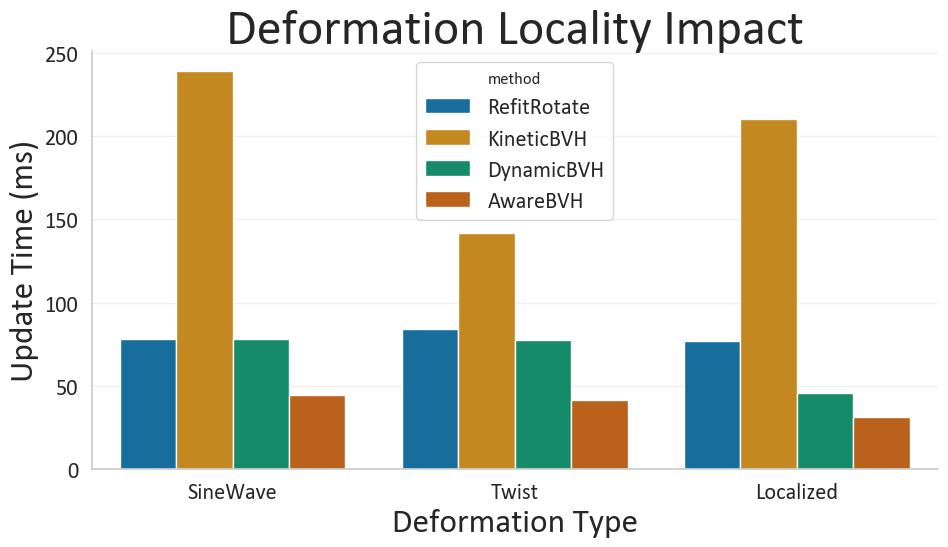

In [368]:
print("\n[FIG 3: Global vs. Localized (Plane Mesh)]")
data_plane = df_stats[df_stats['mesh'] == 'Plane']
if not data_plane.empty:
    max_p = data_plane['triangles'].max()
    data_p_high = data_plane[data_plane['triangles'] == max_p]

    plt.figure(figsize=(10, 6))
    ax3 = sns.barplot(data=data_p_high, x='deformation', y='updateMs', hue='method', order=['SineWave', 'Twist', 'Localized'])
    plt.xlabel("Deformation Type")
    plt.ylabel("Update Time (ms)")
    plt.title("Deformation Locality Impact")
    
    sns.despine(ax=ax3)
    plt.tight_layout()
    plt.savefig("fig3_locality.pdf")
    
    # Print more data: Show the absolute times for AwareBVH and RefitRotate
    for defo in ['SineWave', 'Twist', 'Localized']:
        d_sub = data_p_high[data_p_high['deformation'] == defo]
        if not d_sub.empty:
            aware = d_sub[d_sub['method'] == 'AwareBVH']['updateMs'].values[0]
            refit = d_sub[d_sub['method'] == 'RefitRotate']['updateMs'].values[0]
            print(f"  - {defo:10}: AwareBVH ({aware:.2f}ms) is {refit/aware:.2f}x faster than RefitRotate ({refit:.2f}ms).")


[FIG 4: Vertex Work Reduction (Log Scale)]
  - Suzanne (Max Tris: 251,904): AwareBVH checked 57,133 vertices vs RefitRotate's 755,712 (13.2x reduction).
  - Dragon  (Max Tris: 217,816): AwareBVH checked 58,776 vertices vs RefitRotate's 653,448 (11.1x reduction).
  - Plane   (Max Tris: 264,192): AwareBVH checked 51,256 vertices vs RefitRotate's 792,576 (15.5x reduction).


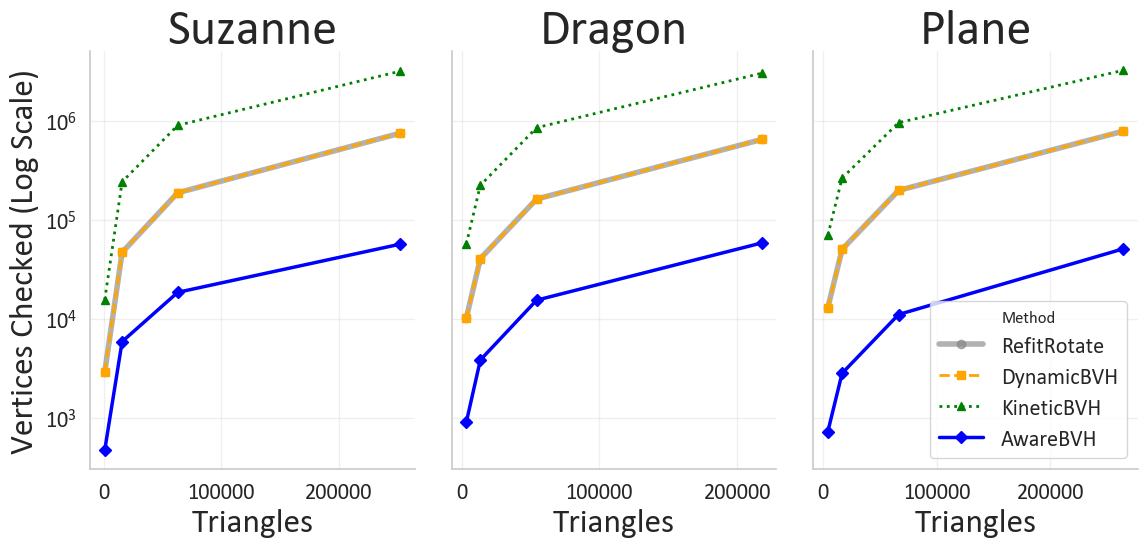

In [ ]:
print("\n[FIG 4: Vertex Work Reduction (Log Scale)]")
fig4, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
for i, mesh in enumerate(['Suzanne', 'Dragon', 'Plane']):
    data_m = df_stats[(df_stats['mesh'] == mesh) & (df_stats['deformation'] == 'Localized')].sort_values('triangles')
    if not data_m.empty:
        for m, style in method_styles.items():
            sub = data_m[data_m['method'] == m]
            if not sub.empty:
                axes[i].plot(sub['triangles'], sub['verticesChecked'], label=m, **style)
        
        axes[i].set_yscale('log')
        axes[i].set_title(f"{mesh}")
        axes[i].set_xlabel("Triangles")
        
        if i == 0:
            axes[i].set_ylabel("Vertices Checked (Log Scale)")
        else:
            axes[i].set_ylabel("") # Hide internal labels
            
        if i == 2: 
            axes[i].legend(loc="lower right", title="Method")
            
        sns.despine(ax=axes[i])
        
        # Print more data: Show vertices checked at the maximum resolution
        mx = data_m[data_m['triangles'] == data_m['triangles'].max()]
        if not mx.empty:
            max_t = mx['triangles'].values[0]
            av = mx[mx['method'] == 'AwareBVH']['verticesChecked'].values[0]
            rv = mx[mx['method'] == 'RefitRotate']['verticesChecked'].values[0]
            print(f"  - {mesh:7} (Max Tris: {max_t:,}): AwareBVH checked {av:,.0f} vertices vs RefitRotate's {rv:,.0f} ({rv/av:,.1f}x reduction).")

plt.tight_layout()
plt.savefig("fig4_vertex_work.pdf")


[FIG 5: Per-Frame Timeline (Normalized Progress)]


C:\Users\o1a2h\AppData\Local\Temp\ipykernel_31468\4024831328.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_f5 = df_f5.groupby(['method', 'run'], group_keys=False).apply(bin_progress)
C:\Users\o1a2h\AppData\Local\Temp\ipykernel_31468\4024831328.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_f5 = df_f5.groupby(['method', 'run'], group_keys=False).apply(bin_progress)
C:\Users\o1a2h\AppData\Local\Temp\ipykernel_31468\4024831328.py:13: FutureWarning: The default of observed=False is deprecated and w

  - RefitRotate : Avg Frame Time: 77.72ms | Peak (Max): 169.41ms | Min: 70.45ms
  - KineticBVH  : Avg Frame Time: 146.85ms | Peak (Max): 294.12ms | Min: 128.61ms
  - DynamicBVH  : Avg Frame Time: 60.55ms | Peak (Max): 121.64ms | Min: 53.24ms
  - AwareBVH    : Avg Frame Time: 58.53ms | Peak (Max): 141.36ms | Min: 53.67ms


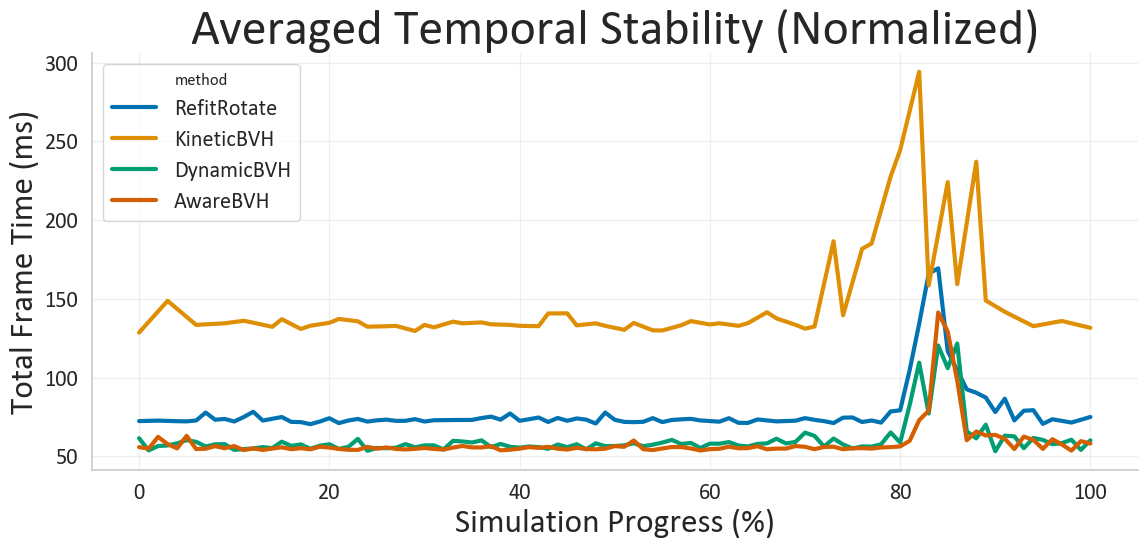

In [370]:
print("\n[FIG 5: Per-Frame Timeline (Normalized Progress)]")
if not df_frames.empty:
    max_d = df_frames[df_frames['mesh'] == 'Dragon']['triangles'].max()
    df_f5 = df_frames[(df_frames['mesh'] == 'Dragon') & (df_frames['triangles'] == max_d) & (df_frames['deformation'] == 'Localized')].copy()

    if not df_f5.empty:
        def bin_progress(g):
            g['prog'] = (g['frame'] - g['frame'].min()) / (g['frame'].max() - g['frame'].min()) * 100
            g['bin'] = g['prog'].round().astype(int)
            return g
            
        df_f5 = df_f5.groupby(['method', 'run'], group_keys=False).apply(bin_progress)
        df_tl = df_f5.groupby(['method', 'bin'])[['totalMs']].mean().reset_index()

        plt.figure(figsize=(12, 6))
        ax5 = sns.lineplot(data=df_tl, x='bin', y='totalMs', hue='method', linewidth=3)
        plt.title("Averaged Temporal Stability (Normalized)")
        plt.xlabel("Simulation Progress (%)")
        plt.ylabel("Total Frame Time (ms)")
        
        sns.despine(ax=ax5)
        plt.tight_layout()
        plt.savefig("fig5_timeline.pdf")
        
        # Print more data: Show Avg, Peak, and Min frame times across the timeline
        for m in df_tl['method'].unique():
            line = df_tl[df_tl['method'] == m]
            avg_ms = line['totalMs'].mean()
            peak_ms = line['totalMs'].max()
            min_ms = line['totalMs'].min()
            print(f"  - {m:12}: Avg Frame Time: {avg_ms:.2f}ms | Peak (Max): {peak_ms:.2f}ms | Min: {min_ms:.2f}ms")